In [1]:
# Celda 1 — Instalación e imports
!pip install scikit-learn nltk --quiet

import re
import pickle
import unicodedata
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from nltk.corpus import stopwords
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from google.colab import files

nltk.download('stopwords')
print('Instalación completa')

Instalación completa


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [7]:
# Celda 2 — Cargar dataset desde CSV
uploaded = files.upload()  # selecciona dataset_resenas_moviles.csv

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f'Archivo cargado: {filename}')
print(f'Total reseñas:   {len(df)}')
print(f'Distribución:    {dict(df["etiqueta"].value_counts())}')

assert 'texto' in df.columns and 'etiqueta' in df.columns
assert set(df['etiqueta'].unique()) == {'positivo', 'negativo', 'neutral'}

textos    = df['texto'].tolist()
etiquetas = df['etiqueta'].tolist()
print('Dataset validado ✓')

Saving dataset.csv to dataset.csv
Archivo cargado: dataset.csv
Total reseñas:   900
Distribución:    {'positivo': np.int64(300), 'neutral': np.int64(300), 'negativo': np.int64(300)}
Dataset validado ✓


In [8]:
# Celda 3 — Preprocesamiento mejorado
# Mejoras: normalización de tildes + manejo de negaciones
STOP_WORDS = set(stopwords.words('spanish')) - {
    'no','ni','nunca','jamás','tampoco','sin','nada','nadie',
    'ningún','ninguno','ninguna'
}
PALABRAS_NEG = {'no','ni','nunca','jamas','tampoco','sin','nada'}

def normalizar(text):
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

def manejar_negaciones(tokens):
    resultado, n = [], 0
    for tok in tokens:
        if tok in PALABRAS_NEG:
            resultado.append(tok); n = 3
        elif n > 0:
            resultado.append('NEG_' + tok); n -= 1
        else:
            resultado.append(tok)
    return resultado

def preprocess(text: str) -> str:
    text = normalizar(text.lower())
    text = re.sub(r'[^\w\s]', '', text)
    tokens = [t for t in text.split() if t not in STOP_WORDS]
    tokens = manejar_negaciones(tokens)
    return ' '.join(tokens)

# Validación con ejemplos de negación
ejemplos = [
    '¡Excelente teléfono! La cámara es increíble.',
    'No funciona como dice la descripción, muy decepcionante.',
    'Nunca más compro aquí, pésimo servicio.',
]
for e in ejemplos:
    print(f'  → {preprocess(e)}')

assert 'NEG_funciona' in preprocess('No funciona bien')
assert 'camara' in preprocess('La cámara es increíble')
print('Preprocesador validado ✓')

  → excelente telefono camara increible
  → no NEG_funciona NEG_dice NEG_descripcion decepcionante
  → nunca NEG_mas NEG_compro NEG_aqui pesimo servicio
Preprocesador validado ✓


In [9]:
# Celda 4 — Split 80/20 y entrenamiento con MultinomialNB
textos_proc = [preprocess(t) for t in textos]

X_train, X_test, y_train, y_test = train_test_split(
    textos_proc, etiquetas,
    test_size=0.20, random_state=42, stratify=etiquetas
)
print(f'Train: {len(X_train)} muestras → {dict(Counter(y_train))}')
print(f'Test:  {len(X_test)}  muestras → {dict(Counter(y_test))}')

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 1), sublinear_tf=True, min_df=2)),
    ('clf',   MultinomialNB(alpha=1.0)),
])
pipeline.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline, textos_proc, etiquetas, cv=cv, scoring='accuracy')
print(f'CV 5-fold: {cv_scores.mean():.2%} ±{cv_scores.std():.2%}')
print('Entrenamiento completado ✓')

Train: 720 muestras → {'positivo': 240, 'neutral': 240, 'negativo': 240}
Test:  180  muestras → {'negativo': 60, 'neutral': 60, 'positivo': 60}
CV 5-fold: 86.78% ±2.69%
Entrenamiento completado ✓


Accuracy en test (20%): 87.78%

Reporte de clasificación:
              precision    recall  f1-score   support

    negativo       0.95      0.93      0.94        60
     neutral       0.82      0.85      0.84        60
    positivo       0.86      0.85      0.86        60

    accuracy                           0.88       180
   macro avg       0.88      0.88      0.88       180
weighted avg       0.88      0.88      0.88       180



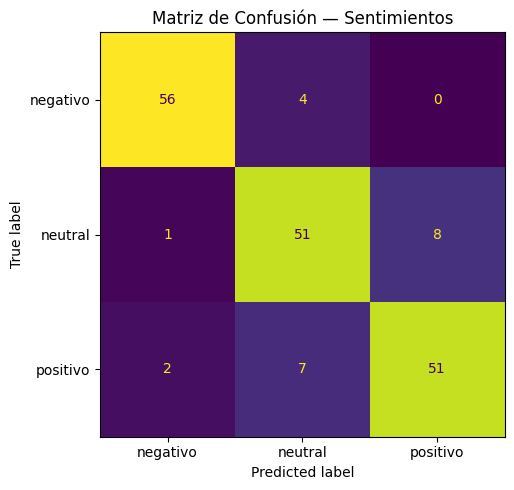

Evaluación completada ✓


In [10]:
# Celda 5 — Evaluación del modelo
y_pred = pipeline.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Accuracy en test (20%): {acc:.2%}')
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred,
      target_names=['negativo', 'neutral', 'positivo']))

cm = confusion_matrix(y_test, y_pred, labels=['negativo', 'neutral', 'positivo'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
       display_labels=['negativo', 'neutral', 'positivo'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)
ax.set_title('Matriz de Confusión — Sentimientos')
plt.tight_layout()
plt.show()

assert acc >= 0.80, f'Accuracy muy baja: {acc:.2%}'
print('Evaluación completada ✓')

In [11]:
# Celda 6 — Exportar modelo y descargar
MODEL_FILENAME = 'sentiment_model.pkl'

with open(MODEL_FILENAME, 'wb') as f:
    pickle.dump(pipeline, f)

print(f"Modelo guardado como '{MODEL_FILENAME}'")
print(f"Tamaño: {__import__('os').path.getsize(MODEL_FILENAME):,} bytes")

with open(MODEL_FILENAME, 'rb') as f:
    loaded = pickle.load(f)

pruebas = [
    ('Excelente teléfono, cámara increíble y batería todo el día', 'positivo'),
    ('No funciona, pésimo producto llegó roto',                   'negativo'),
    ('El teléfono cumple su función básica sin nada especial',     'neutral'),
]
print('\nVerificación rápida:')
for texto, esperado in pruebas:
    pred = loaded.predict([preprocess(texto)])[0]
    conf = max(loaded.predict_proba([preprocess(texto)])[0])
    ok   = '✓' if pred == esperado else '✗'
    print(f'  {ok} {texto[:48]}... → {pred} ({conf:.0%})')

print('\nModelo serializado correctamente ✓')
files.download(MODEL_FILENAME)
print('Descarga iniciada — guarda el archivo en web/models/')

Modelo guardado como 'sentiment_model.pkl'
Tamaño: 82,973 bytes

Verificación rápida:
  ✗ Excelente teléfono, cámara increíble y batería t... → neutral (50%)
  ✓ No funciona, pésimo producto llegó roto... → negativo (50%)
  ✗ El teléfono cumple su función básica sin nada es... → positivo (37%)

Modelo serializado correctamente ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada — guarda el archivo en web/models/
